# Phân tích Dữ liệu ICDAR Robust Reading
Trong notebook này, chúng ta sẽ xem xét cấu trúc và hình ảnh của tập dữ liệu ICDAR Robust Reading (Detection & Recognition).
Sau đó chúng ta sẽ sinh thử ảnh tiếng Việt bằng code Synthetic để đắp vào tập Recognition.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import random

# Hỗ trợ tiếng Việt trên đồ thị
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial']

def imshow_rgb(img, title="", ax=None):
    if ax is None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')

## 1. Phân tích tập Detection
Tập Detection chứa các ảnh lớn (full screen/document) kèm tọa độ 8 điểm của các khung chữ.

Tổng số ảnh Detection: 400


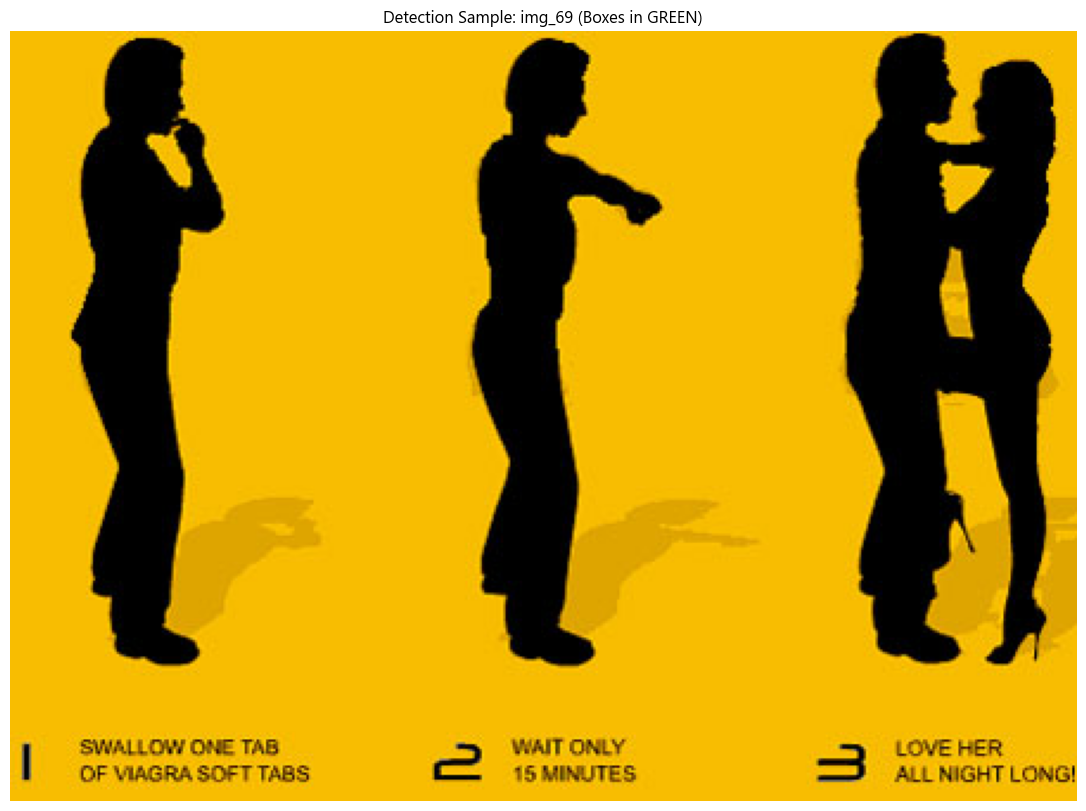

In [2]:
det_imgs = glob.glob('../data/raw/Detection/imgs/*.png') + glob.glob('../data/raw/Detection/imgs/*.jpg')
print(f"Tổng số ảnh Detection: {len(det_imgs)}")

if det_imgs:
    sample_img_path = random.choice(det_imgs)
    img_name = Path(sample_img_path).stem
    gt_path = f"../data/raw/Detection/gts/gt_{img_name}.txt"

    img = cv2.imread(sample_img_path)
    if img is not None:
        try:
            with open(gt_path, 'r', encoding='utf-8-sig') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split(',')
                if len(parts) >= 8:
                    try:
                        pts = [int(float(p)) for p in parts[:8]]
                        pts = np.array(pts).reshape((-1, 1, 2))
                        cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
                    except ValueError:
                        pass
        except FileNotFoundError:
            print("Không tìm thấy nhãn cho ảnh này")

        plt.figure(figsize=(15, 10))
        imshow_rgb(img, title=f"Detection Sample: {img_name} (Boxes in GREEN)")
        plt.show()

## 2. Phân tích tập Recognition
Tập Recognition chứa ảnh từng dòng chữ đã cắt sẵn, phục vụ trực tiếp cho mô hình CRNN.

Tổng số ảnh Recognition: 3567


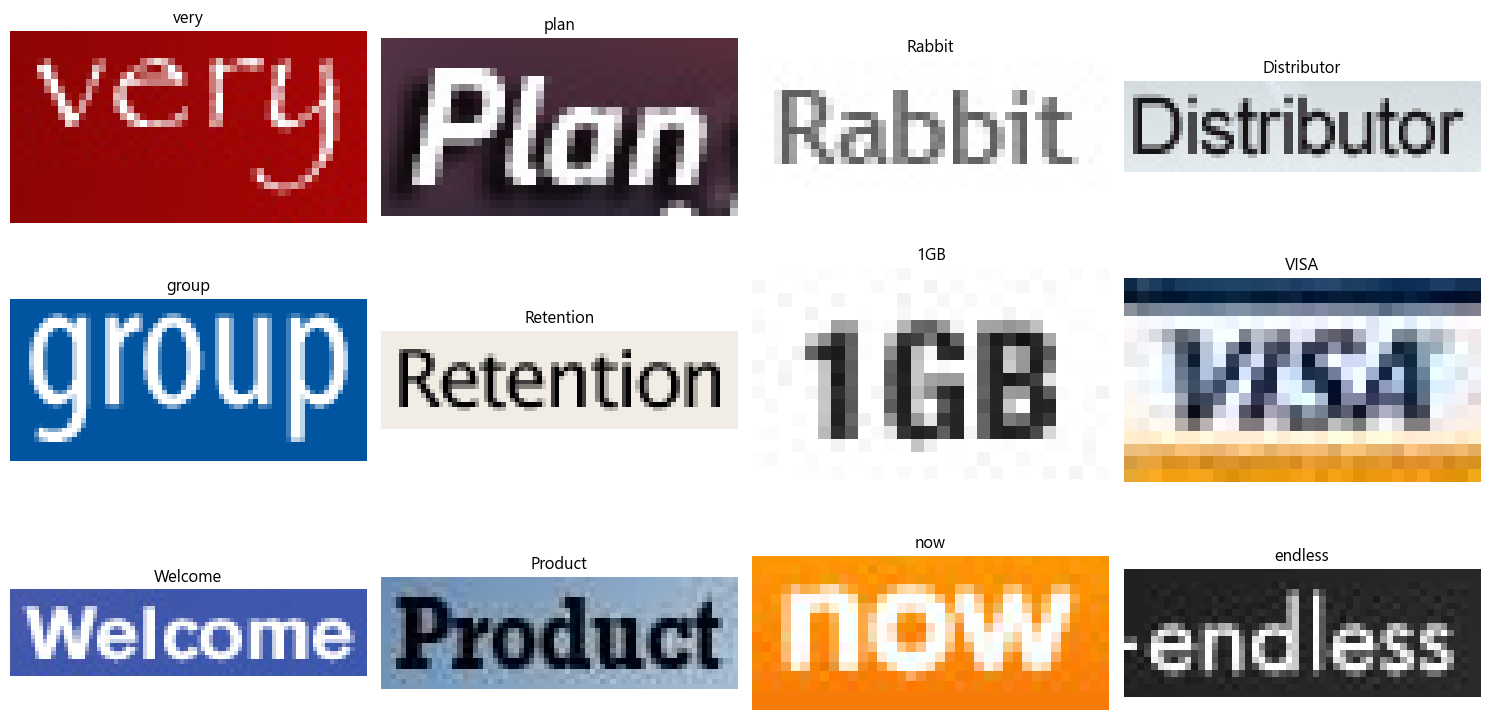

In [3]:
gt_rec_path = '../data/raw/Recognition/gt.txt'
rec_samples = []
try:
    with open(gt_rec_path, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split(', ', 1)
            if len(parts) == 2:
                img_file = parts[0]
                label = parts[1].strip('"')
                rec_samples.append((img_file, label))

    print(f"Tổng số ảnh Recognition: {len(rec_samples)}")

    if rec_samples:
        fig, axes = plt.subplots(3, 4, figsize=(15, 8))
        axes = axes.flatten()
        samples_to_show = random.sample(rec_samples, min(12, len(rec_samples)))
        for i, (img_file, label) in enumerate(samples_to_show):
            img_path = f"../data/raw/Recognition/{img_file}"
            img = cv2.imread(img_path)
            if img is not None:
                imshow_rgb(img, title=label, ax=axes[i])
            else:
                axes[i].set_title("Image not found")
                axes[i].axis('off')
        plt.tight_layout()
        plt.show()
except FileNotFoundError:
    print("Không tìm thấy file gt.txt trong tập Recognition")

## 3. Thử nghiệm bổ sung tiếng Việt bằng Synthetic Data
Vì tập Recognition hiện tại thiếu tiếng Việt, ta có thể dùng code Data Generation hiện có để sinh ảnh bù vào!

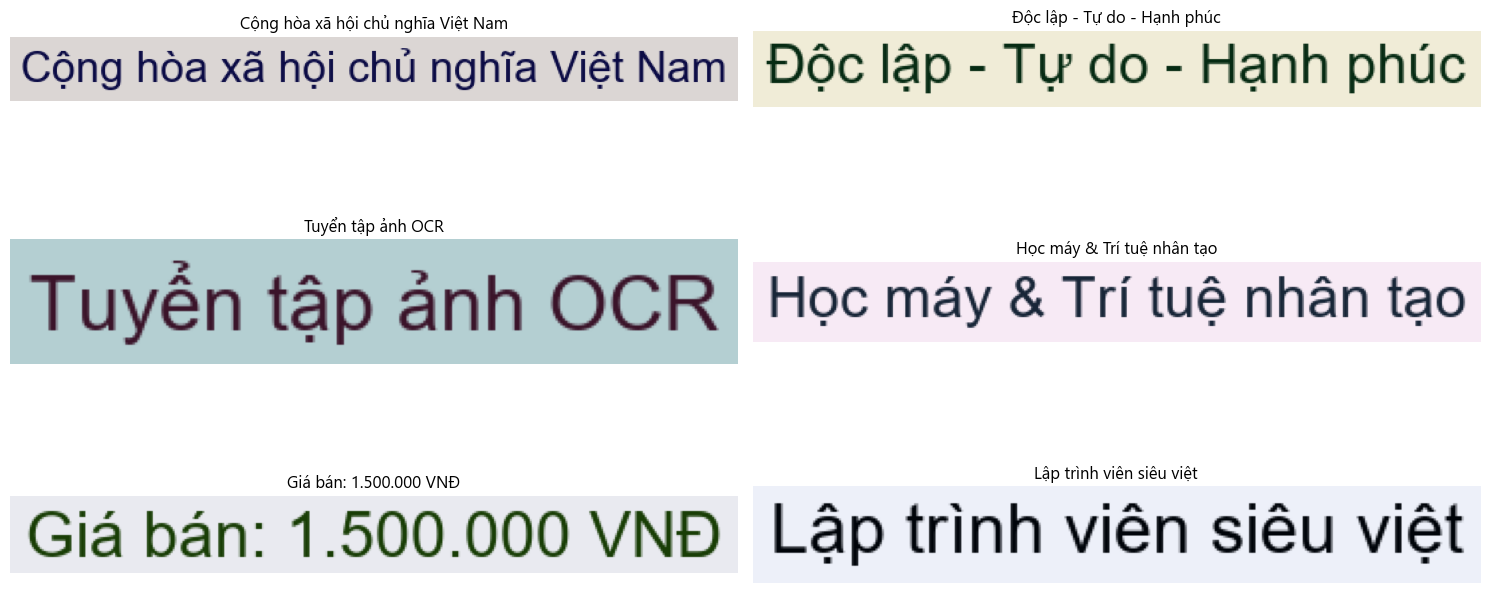

In [4]:
import sys
sys.path.append('..')  # Để import được src
from src.data_gen import generate_sample

# Bạn có thể thay bằng đường dẫn tới font tiếng Việt trong máy (Vd: Arial, Times New Roman)
font_path = "C:/Windows/Fonts/arial.ttf"

vietnamese_texts = [
    "Cộng hòa xã hội chủ nghĩa Việt Nam",
    "Độc lập - Tự do - Hạnh phúc",
    "Tuyển tập ảnh OCR",
    "Học máy & Trí tuệ nhân tạo",
    "Giá bán: 1.500.000 VNĐ",
    "Lập trình viên siêu việt"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 8))
axes = axes.flatten()
for i, text in enumerate(vietnamese_texts):
    try:
        img = generate_sample(text, font_path, font_size=32)
        if img is not None:
            imshow_rgb(img, title=text, ax=axes[i])
        else:
            axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"Lỗi: {e}")
        axes[i].axis('off')
        
plt.tight_layout()
plt.show()